# Solving Non-linear Equations

## Systems of Equations
For **linear** systems of equations, we know that they can always be solved if there are as many equations as there are variables (i.e. we have a square coefficient matrix).

For **non-linear** equations, there may be situations where solutions may *only* be determined numerically.

```{note}Linear vs. Non-Linear
:class: dropdown
**Linear**
any equation of the form: 
$$ a_1 x_1 + a_2 x_2 + .. a_n x_n = v$$
**Non-linear**  
Can include:
+ polynomials: $$ a_1 x_1^N + ... + a_n x_n = v$$ 
+ exponentials/logs: $$ 2x - log(x) = 0, x - e^{2x} = 5$$
+ trig functions: $$ sin(x) - x^2 = x, tan(x) = log(x)$$
etc.
```

## Non-linear methods
Most non-linear methods take advantage of what we can algorithmically infer about the shape and behavior of functions in order to iteratively find their solutions --
like a kind of brute force curve sketching. 

Broadly, there are many applications for these methods within physics and beyond, including but not limited to root-finding, optimization problems, statistical fits, etc. These methods are also widely foundational for solving differential equations, as we'll see in the coming weeks.

(relaxation)=
### Relaxation Method
If we have some non-linear function that we can write as: $f(x) = x$ for which we need to solve for $x$, we can try relaxation!

+ We start with a guess for $x=x_0$ and
+ evaluate $x_1 = f(x_0)$, 
+ iterate with the new value $x_2 = f(x_1)$ 
+ until we satisfy the condition $x_N = f(x_N)$

In this case, we iterate until $x_i$ **relaxes** to a solution.

<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} icc_5-2
```

```{tip}
We can extend this method and formulation for systems of non-linear equations of multiple variables if we can write each equation in the form of a function equal to a variable in the system:
$$ x = f(x,y), y = g(x,y) $$
```

#### Troubleshooting Relaxation
+ Requires an equation of the form $f(x) = x$  
    $\rightarrow$ try rearranging the equation or using a change of variables.
+ Does not guarantee a unique solution, result may depend on the value of the initial guess   
    $\rightarrow$ better initial guesses can yield better results, some idea of where you expect the solution to be is helpful
+ Convergence is not guaranteed, the method can yield an oscillating solution between two values rather than relaxing to one solution   
    $\rightarrow$ evaluate the **convergence condition** of $f(x)$, if you can rearrange to find the inverse, try to solve that instead: $f^{-1}(x) = x$ 

```{note} Convergence of Relaxation
:class: dropdown
For an exact solution $x^*$, the Taylor expansion about a point $x$ near $x^*$, the value after an iteration $x_i$ is given by:
$$x_i = f(x) = f(x^*) + (x - x^*) f'(x^*) + ...$$
since we know $f(x^*) = x^*$ and neglecting higher order terms, the distance to the true solution is given by:
$$ x_i - x^{*} = (x-x^*)f'(x^{*})$$

Thus, if:
+ $| f'(x_*) | < 1$, the distance from the solution will grow shorter with each iteration, *the method will converge*
+ $| f'(x_*) | > 1$, the distance from the soluation will grow longer with each iteration, *the method will diverge*

In effect,  $| f'(x_*) |$ gives the rate of convergence for an iteration, which we can use to estimate the error on the solution (see Newman Eqs. 6.83 & 6.87). 
```



### Bisection Method (Binary Search)
If we have non-linear equations for a *single variable* in x, with a solution that exists within a specified interval, we can find a solution to $f(x) = 0$ by finding the roots or zeros of $f(x)$ using **bisection**.

+ Given the bounds of some interval between: $x_1$ and $x_2$, evaluate $f(x_1)$ and $f(x_2)$
+ If $f(x_1)$ has the opposite sign of $f(x_2)$, a root must lie between them
+ Bisect the interval, and evaluate $f$ at the midpoint $x_m = (x_1 + x_2)/2$.
+ If $f(x_m)$ has the opposite sign of $f(x_1)$, a root must lie in the 1st half interval, otherwise it is in the 2nd half interval. 
+ Iterate the process on each successively smaller half interval.

Bisection can be thought of as a type of [**binary search**](https://en.wikipedia.org/wiki/Binary_search) algorithm, in which you look for a condition or event by evaluating it whether it occurs within successive half intervals. 

#### Troubleshooting Bisection
If $f(x_1)$ has the same sign as $f(x_2)$, then we can't iterate to find the next half interval
+ the function has even number of roots in the interval
    \rightarrow  start with a better guess for a specific root in the interval
+ the function may not have a root in the interval
    \rightarrow start with a smaller interval and double the distance between $x_1$ and $x_2$ until the interval encloses a root, then bisect
+ the function touches zero but doesn't cross it
    \rightarrow bisection won't work here, it works best if you have some idea about where your function is actually positive and negative






### Newton-Raphson Method
If we have a differentiable function $f(x)$ for which we can evaluate $f'(x)$, and for which $f''(x)$ is finite, we can use the **Newton-Raphson** method to find the solution to $f(x)=0$ by using the derivative to narrow down the location of the root.

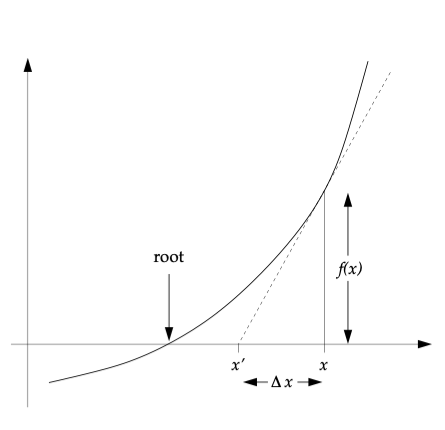

+ Start from some guess $x_0 = x$.
+ The slope of the  tanget line at $f(x_0)$ is the derivate $f'(x_0) = f(x_0)/\Delta x$, where $\Delta x$ is the distance to the new guess.
+ Calculate a new guess $x_1 = x' = x_0 - \Delta x = x_0 - \frac{f(x_0)}{f'(x_0)}$
+ Keep iterating until zero is found using: 
$$ x_{i+1} = x_i - \frac{f(x_i)}{f'(x_i)}$$

```{tip}
Newton-Raphson is one of the fastest and most-used methods to find the root of a function, typically converging within a few iterations.
```


<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} icc_5-3
```

#### Troubleshooting Newton-Raphson

+ The iterations oscillate between different roots depending on the choice of $x_0$
    \rightarrow if there are multiple roots close together, small variations in $x_0$ may cause jumping between different tangent trajectories
+ The iterations oscillate between different values that aren't roots depending on choice of $x_0$
    \rightarrow the shape of $f(x)$ may mean $x_0$ lies too close to the intersection of multiple tangent lines, refine the initial guess
    
:question

```{embed} ex_5-4
```

```{tip} Newton Raphson in N-dimensions
If we have $N$ equations with $N$ variables:
$$f_1(x_1,\ldots,x_n)=0\\ \vdots \\
f_N(x_1,\ldots,x_n)=0$$

In vector notation, the Taylor expansion about the roots gives:
$$\mathbf{f}(\mathbf{x}^*) = \mathbf{f}(\mathbf{x}) + \nabla \mathbf{f} \cdot (\mathbf{x}^* - \mathbf{x}) = 0 \\
\nabla \mathbf{f} \cdot \Delta \mathbf{x} = \mathbf{f}(\mathbf{x})$$

where $\nabla \mathbf{f}$ is the $N\times N$ **Jacobian** matrix with elements are $\frac{\partial f_i}{\partial x_j}$ and  $ \Delta \mathbf{x}$ is vector for the distance from the roots for all variables.

To find the new iteration ${\bf x}_{i+1} = {\bf x}_i - \Delta \mathbf{x}$, we would then use [Gaussian Elimination](./5a_lineareqs.ipynb) to solve 
$\nabla \mathbf{f} \cdot \Delta \mathbf{x} = \mathbf{f}(\mathbf{x})$ for  $ \Delta \mathbf{x}$ as a system of linear equations in the form ${\bf A}{\bf x} = {\bf v}$. 
```

<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} icc_5-4
```




### Secant Method
Derivatives are very helpful for root-finding, but as we've discussed, many times we do not know the functional continuous form of $f(x)$ or $f'(x)$!
In this case, if we recast the Newton Raphson iteration using a [numerical derivative](./4b_derivatives.ipynb), we could find the roots by the **secant method**. 

+ Start with two points $x_{i+1}$ and $x_{i}$
+ Approximate the derivative between them as: $$f'(x_{i+1}) = \frac{f(x_{i+1}) - f(x_i)}{x_{i+1}-x_i}$$
+ Iterate to find the next point: $$x_{i+2} = x_{i+1} - f(x_{i+1})\frac{x_{i+1}-x_i}{f(x_{i+1}) - f(x_i)}$$

Note that we now need information across two previous points to iterate, but this method is functionally equivalent to Newton's method. 


### Finding Maxima and Minima

```{note}
Calculus tells us that finding an extrema of a function $f(x)$ comes down to solving for the zeros of it's derivative, that is solving for $f'(x) = 0$. 
This means that if we know $f'(x)$ we can use any of the standard root-finding methods from above to find the maxima/minima of $f(x)$.
```

Within the context of finding minima/maxima, these methods have their own named variations:
+ **Golden Ratio Search**: Bisection, but instead of comparing the sign of $f(x)$ at the interval bounds, we compare on which intervals $f$ is consecutively increasing or decreasing, across 3 sub-intervals. The spacing of the intervals is optimized by the golden ratio: $$\frac{x_4 - x_1}{x_3 - x_1} = \frac{1 + \sqrt{5}}{2}$$ and the solution is given by $\frac{1}{2}(x_2 + x_3)$
+ **Gauss-Newton Method**: Newton-Raphson, but for the derivative of $f$: $$x_{i+1} = x_i - \frac{f'(x_i)}{f''(x_i)}$$. *If the second derivative is not able to be evaluated, set it's reciprocal as a constant $\gamma = 1/f''(x_i)$ (with some guess) and then it is the **Gradient Descent Method**:
    + (Newton) $$x_{i+1} = x_i - \gamma f'(x_i)$$

    + (Secant) $$x_{i+2} = x_{i+1} - \gamma \frac{f(x_{i+1})-f(x_i)}{x_{i+1}-x_i}$$




